<a href="https://colab.research.google.com/github/HMBinara/ML_Project/blob/main/Demand_0Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv('demand_forecasting.csv')

Saving demand_forecasting.csv to demand_forecasting (1).csv


In [4]:
df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59


In [6]:
df.shape

(76000, 16)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76000 entries, 0 to 75999
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                76000 non-null  object 
 1   Store ID            76000 non-null  object 
 2   Product ID          76000 non-null  object 
 3   Category            76000 non-null  object 
 4   Region              76000 non-null  object 
 5   Inventory Level     76000 non-null  int64  
 6   Units Sold          76000 non-null  int64  
 7   Units Ordered       76000 non-null  int64  
 8   Price               76000 non-null  float64
 9   Discount            76000 non-null  int64  
 10  Weather Condition   76000 non-null  object 
 11  Promotion           76000 non-null  int64  
 12  Competitor Pricing  76000 non-null  float64
 13  Seasonality         76000 non-null  object 
 14  Epidemic            76000 non-null  int64  
 15  Demand              76000 non-null  int64  
dtypes: f

In [8]:
df['Date'] =pd.to_datetime(df['Date'])

In [9]:
df.dtypes

,0
Date,datetime64[ns]
Store ID,object
Product ID,object
Category,object
Region,object
Inventory Level,int64
Units Sold,int64
Units Ordered,int64
Price,float64
Discount,int64


In [10]:
df.isnull().sum()

,0
Date,0
Store ID,0
Product ID,0
Category,0
Region,0
Inventory Level,0
Units Sold,0
Units Ordered,0
Price,0
Discount,0


In [11]:
df.duplicated().sum()

np.int64(0)

In [16]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Date,76000,2023-01-15 12:00:00,2022-01-01 00:00:00,2022-07-09 18:00:00,2023-01-15 12:00:00,2023-07-24 06:00:00,2024-01-30 00:00:00,NaN
Inventory Level,76000.0,301.062842,0.0,136.0,227.0,408.0,2267.0,226.510161
Units Sold,76000.0,88.827316,0.0,58.0,84.0,114.0,426.0,43.994525
Units Ordered,76000.0,89.090645,0.0,0.0,0.0,121.0,1616.0,162.404627
Price,76000.0,67.726028,4.74,31.9975,64.5,95.83,228.03,39.377899
Discount,76000.0,9.087039,0.0,5.0,10.0,10.0,25.0,7.475781
Promotion,76000.0,0.328947,0.0,0.0,0.0,1.0,1.0,0.469834
Competitor Pricing,76000.0,69.454029,4.29,32.62,65.7,97.9325,261.22,40.943818
Epidemic,76000.0,0.2,0.0,0.0,0.0,0.0,1.0,0.400003
Demand,76000.0,104.317158,4.0,71.0,100.0,133.0,430.0,46.964801


In [15]:
df.describe(include='object').T

,count,unique,top,freq
Store ID,76000,5,S001,15200
Product ID,76000,20,P0001,3800
Category,76000,5,Groceries,30400
Region,76000,4,North,30400
Weather Condition,76000,4,Cloudy,24360
Seasonality,76000,4,Winter,21000


In [17]:
df.head(2)

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229


In [19]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['weakday'] =df['Date'].dt.day_name()

In [21]:
df.head(2)

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand,Year,Month,Day,weakday
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115,2022,1,1,Saturday
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229,2022,1,1,Saturday


In [24]:
df['Discount Price'] =df['Price']*(1-df['Discount']/100)

In [26]:
df['Sell Through Rate'] = df['Units Sold']/df['Inventory Level']

In [27]:
df['Sell Through Rate'].describe()

,Sell Through Rate
count,75594.000000
mean,0.437580
std,0.298007
min,0.003150
25%,0.190807
50%,0.350475
75%,0.642276
max,1.000000


In [35]:
# Aggregate 'Demand' by 'Category' (mean, sum, std), sort by total demand in descending order,
# and reset the index for a clean output.

df.groupby('Category')['Demand'].agg(['mean','sum','std']).sort_values(by = 'sum',ascending = False).reset_index()

,Category,mean,sum,std
0,Groceries,120.976447,3677684,48.362730
1,Clothing,112.619737,1369456,41.022968
2,Furniture,73.581140,1006590,32.336141
3,Toys,92.606955,985338,46.170390
4,Electronics,97.482018,889036,40.557859


In [36]:
# Group the data by both 'Region' and 'Seasonality', then calculate
# the average ('mean') demand for each combination of these categories.

df.groupby(['Region','Seasonality'])['Demand'].mean()

Region  Seasonality
East    Autumn         106.353297
        Spring         100.168478
        Summer         115.388315
        Winter         104.273571
North   Autumn         103.065797
        Spring          97.399457
        Summer         112.843750
        Winter         102.017738
South   Autumn         104.464560
        Spring         100.328804
        Summer         115.089946
        Winter         107.733095
West    Autumn         100.165385
        Spring          93.219293
        Summer         108.111141
        Winter         100.988810
Name: Demand, dtype: float64

In [37]:
# Group the data by 'Promotion' and calculate the average ('mean') demand
# for each promotion category to evaluate its impact on demand levels.

df.groupby('Promotion')['Demand'].mean()

,Demand
Promotion,
0,95.026843
1,123.269400


In [38]:
# Create a pivot table to summarize the average ('mean') demand,
# with 'Month' as rows and 'Category' as columns,
# enabling comparison of demand patterns across categories over time.

pd.pivot_table(df,values="Demand",index="Month",columns="Category",aggfunc="mean")

Category,Clothing,Electronics,Furniture,Groceries,Toys
Month,,,,,
1,126.997962,99.519022,75.690821,117.399457,94.242236
2,128.966518,84.184524,61.625992,103.522768,68.885204
3,105.835685,108.120968,84.015233,126.561694,128.273041
4,106.972917,85.916667,63.005556,105.111250,85.753571
5,108.650202,79.577957,56.036738,98.637903,71.756912
6,105.670833,106.922222,79.908333,147.772500,100.825000
7,107.838710,87.418011,66.156810,128.744355,74.366359
8,107.871976,109.733871,83.524194,149.875403,102.794931
9,105.118750,105.015278,81.854630,122.239167,102.722619


**Data Visulization**

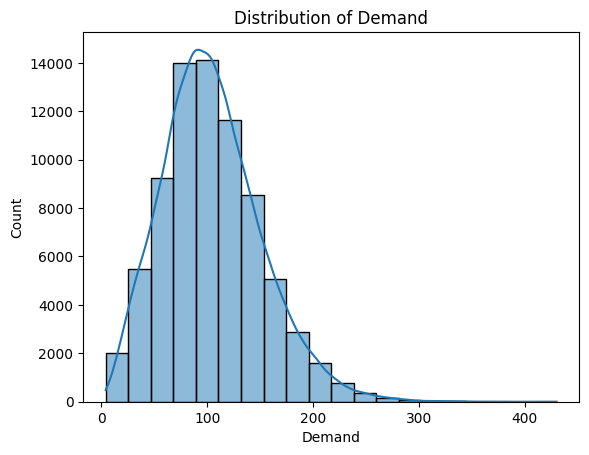

In [39]:
sns.histplot(df['Demand'],bins=20,kde = True)
plt.title('Distribution of Demand')
plt.show()

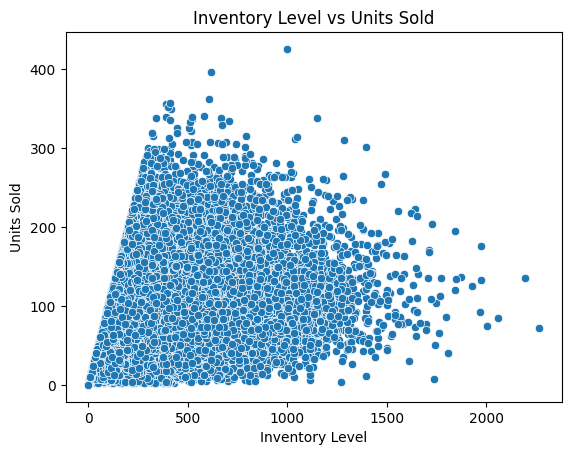

In [43]:
sns.scatterplot(data=df, x = "Inventory Level", y="Units Sold")
plt.title("Inventory Level vs Units Sold")
plt.show()